In [32]:
import uproot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Apri il file
file = uproot.open("PROVA_SBRUCE_TREE_MAPLE_NICOLA_RUN4.root")

# Vedi cosa contiene (tree, histogram, ecc.)
print(file.keys())          # lista di oggetti nel file
print(file.classnames())    # tipo di ogni oggetto (TTree, TH1F, ecc.)

tree_nu = file["events/selectedNu"]   # sostituisci con il nome reale
print(tree_nu.keys())             # nomi delle colonne (branch)

tree_reco = file["events/selectedReco"]
print(tree_reco.keys())

df_nu = tree_nu.arrays(library="pd") # converte tutto in un pandas DataFrame
df_reco = tree_reco.arrays(library="pd")

['events;1', 'events/POT;2', 'events/POT;1', 'events/Livetime;2', 'events/Livetime;1', 'events/selectedNu;1', 'events/selectedReco;1']
{'events;1': 'TDirectory', 'events/POT;2': 'TH1D', 'events/POT;1': 'TH1D', 'events/Livetime;2': 'TH1D', 'events/Livetime;1': 'TH1D', 'events/selectedNu;1': 'TTree', 'events/selectedReco;1': 'TTree'}
['true_Enu', 'True_visible_Enu', 'Genie_mode', 'Pass_cut', 'Eff_raster_angle', 'True_protons', 'Eff_raster_nuscore', 'Eff_cryosel', 'Run', 'Subrun', 'Evt']
['recoE', 'Reco_class', 'Muon_length', 'Proton_length_leading', 'Proton_kinetic_leading', 'Proton_chi2mu', 'Proton_chi2pro', 'Muon_chi2mu', 'Muon_chi2pro', 'Vertex_x', 'Vertex_y', 'Vertex_z', 'Muon_endx', 'Muon_endy', 'Muon_endz', 'Proton_endx', 'Proton_endy', 'Proton_endz', 'Transverse_angle', 'T3D_angle_mup', 'deltaPt', 'Transverse_mom_reco_mu', 'Transverse_mom_reco_pro', 'Number_protons', 'Barycenter_delta', 'Muon_trackScore', 'Proton_trackScore', 'Nu_score', 'CryoSel', 'Run', 'Subrun', 'Evt']


In [33]:
print(df_nu.columns)

Index(['true_Enu', 'True_visible_Enu', 'Genie_mode', 'Pass_cut',
       'Eff_raster_angle', 'True_protons', 'Eff_raster_nuscore', 'Eff_cryosel',
       'Run', 'Subrun', 'Evt'],
      dtype='str')


In [34]:
print(df_reco.columns)

Index(['recoE', 'Reco_class', 'Muon_length', 'Proton_length_leading',
       'Proton_kinetic_leading', 'Proton_chi2mu', 'Proton_chi2pro',
       'Muon_chi2mu', 'Muon_chi2pro', 'Vertex_x', 'Vertex_y', 'Vertex_z',
       'Muon_endx', 'Muon_endy', 'Muon_endz', 'Proton_endx', 'Proton_endy',
       'Proton_endz', 'Transverse_angle', 'T3D_angle_mup', 'deltaPt',
       'Transverse_mom_reco_mu', 'Transverse_mom_reco_pro', 'Number_protons',
       'Barycenter_delta', 'Muon_trackScore', 'Proton_trackScore', 'Nu_score',
       'CryoSel', 'Run', 'Subrun', 'Evt'],
      dtype='str')


In [35]:

chiavi = ['Run', 'Subrun', 'Evt']

merged = df_reco.merge(df_nu[chiavi], on=chiavi, how='inner')

correctly_classified = len(merged)

efficiency = correctly_classified / df_nu.shape[0]
purity = correctly_classified / df_reco.shape[0]

print('efficiency: ', efficiency)
print('purity: ', purity)

efficiency:  0.5056959892146949
purity:  0.7493008389932081


In [36]:
mask = (df_reco['Reco_class'] == 1) | (df_reco['Reco_class'] == 2)
correctly_classified_slice = df_reco[mask]
efficiency_slice = correctly_classified_slice.shape[0] / df_nu.shape[0]
purity_slice = correctly_classified_slice.shape[0] / df_reco.shape[0]
print('efficiency: ', efficiency_slice)
print('purity: ', purity_slice)

efficiency:  0.5038085608358611
purity:  0.7465041949660407


In [29]:
bin_edges = np.array([0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0, 1.25, 1.5, 2.0, 2.5])
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

def get_df(filename) : 
    file = uproot.open(filename)

    tree_nu = file["events/selectedNu"]  

    tree_reco = file["events/selectedReco"]

    df_nu = tree_nu.arrays(library="pd") 
    df_reco = tree_reco.arrays(library="pd")

    #return df_nu[(df_nu['True_protons']==1)],df_reco[df_reco['Number_protons'] > 1]
    return df_nu,df_reco

def get_eff_pur(df_reco, df_nu, color, label) :
    #mask = (df_reco['Reco_class'] == 1) | (df_reco['Reco_class'] == 2)
    #correctly_classified_slice = df_reco[mask]
    #efficiency_slice = correctly_classified_slice.shape[0] / df_nu.shape[0]
    #purity_slice = correctly_classified_slice.shape[0] / df_reco.shape[0]

    chiavi = ['Run', 'Subrun', 'Evt']

    merged = df_nu.merge(df_reco[chiavi], on=chiavi, how='inner')

    correctly_classified = len(merged)

    efficiency = correctly_classified / df_nu.shape[0]
    purity = correctly_classified / df_reco.shape[0]
    
    counts_all, _ = np.histogram(df_nu['true_Enu'], bins=bin_edges)

    counts_sel, _ = np.histogram(merged['true_Enu'], bins=bin_edges)

    ratio = np.zeros_like(counts_all, dtype=float)
    mask = counts_all > 0
    ratio[mask] = counts_sel[mask] / counts_all[mask]

    errors = np.zeros_like(ratio)
    errors[mask] = np.sqrt(ratio[mask] * (1 - ratio[mask]) / counts_all[mask])

    plt.stairs(ratio, bin_edges, color=color, linewidth=2, alpha=1, label=f'{label} \neff. : {efficiency*100:.1f}%, pur. w/out off. : {purity*100:.1f}%')

    # Plot error bars
    plt.errorbar(bin_centers, ratio, yerr=errors, fmt='o', markersize=3, color=color, alpha=1)


    return efficiency, purity

(0.0, 0.7)

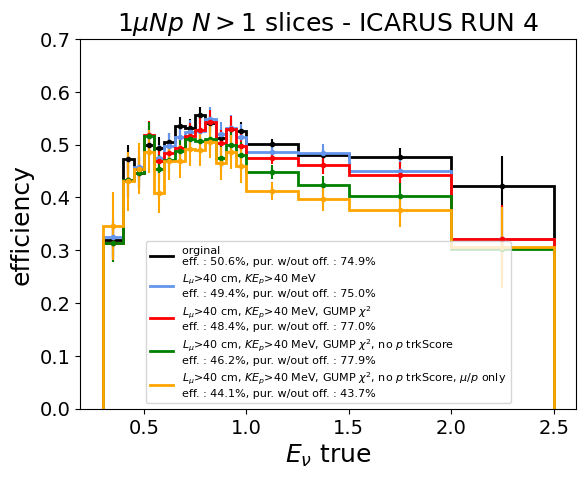

In [31]:
df_nu_standard, df_reco_standard = get_df('PROVA_SBRUCE_TREE_MAPLE_NICOLA_RUN4.root')
df_nu_muL_pKE, df_reco_muL_pKE = get_df('TOT_SBRUCE_TREE_MAPLE_NICOLA_RUN4_MU_L_40_PRO_KE_40.root')
df_nu_muL_pKE_pid, df_reco_muL_pKE_pid = get_df('TOT_SBRUCE_TREE_MAPLE_NICOLA_RUN4_MU_L_40_PRO_KE_40_CHI2_VAR.root')
df_nu_muL_pKE_pid_trackscore, df_reco_muL_pKE_pid_trackscore = get_df('TOT_SBRUCE_TREE_MAPLE_NICOLA_RUN4_MU_L_40_PRO_KE_40_CHI2_VAR_TRACKSCORE_VAR.root')
df_nu_muL_pKE_pid_trackscore_vis, df_reco_muL_pKE_pid_trackscore_vis = get_df('TOT_SBRUCE_TREE_MAPLE_NICOLA_RUN4_MU_L_40_PRO_KE_40_CHI2_VAR_TRACKSCORE_VAR_VISIBLE_VAR.root')

eff_standard, pur_standard = get_eff_pur(df_reco_standard,df_nu_standard,'black','orginal')
eff_muL_pKE, pur_muL_pKE = get_eff_pur(df_reco_muL_pKE, df_nu_muL_pKE, 'cornflowerblue', r'$L_{\mu}$>40 cm, $KE_p$>40 MeV')
eff_muL_pKE_pid, pur_muL_pKE_pid = get_eff_pur(df_reco_muL_pKE_pid, df_nu_muL_pKE_pid, 'red', r'$L_{\mu}$>40 cm, $KE_p$>40 MeV, GUMP $\chi^2$')
eff_muL_pKE_pid_trackscore, pur_muL_pKE_pid_trackscore = get_eff_pur(df_reco_muL_pKE_pid_trackscore, df_nu_muL_pKE_pid_trackscore, 'green', r'$L_{\mu}$>40 cm, $KE_p$>40 MeV, GUMP $\chi^2$, no $p$ trkScore')
eff_muL_pKE_pid_trackscore_vis, pur_muL_pKE_pid_trackscore_vis = get_eff_pur(df_reco_muL_pKE_pid_trackscore_vis, df_nu_muL_pKE_pid_trackscore_vis, 'orange', r'$L_{\mu}$>40 cm, $KE_p$>40 MeV, GUMP $\chi^2$, no $p$ trkScore, $\mu$/$p$ only')

plt.legend(loc='lower center', fontsize=8)
plt.xlabel(r'$E_{\nu}$ true', fontsize = 18)
plt.ylabel('efficiency', fontsize = 18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title(r'$1\mu Np$ $N>1$ slices - ICARUS RUN 4', fontsize = 18)
plt.ylim(0,0.7)

